# NHANES Data Analysis & Obesity Prediction
## 02 — Data Cleaning and Preparation

## This notebook performs data quality checks, handles missing values, removes invalid records, and prepares the dataset for analysis. It also creates an Obesity indicator and checks for outliers in key numeric variables.

## 1. Load Dataset

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("data\merged_data.csv")

## 2. Initial Data Quality Checks

### 2.1 Duplicate Records

In [2]:
df.duplicated().sum()

np.int64(0)

### 2.2 Missing Values Overview

In [3]:
df.isnull().sum()

SEQN           0
RIAGENDR       0
RIDAGEYR       0
RIDRETH3       0
DMDEDUC2    8552
DMDMARTZ    8553
INDFMPIR    2994
BMXBMI      1552
BMXWAIST    2396
BMXARMC     1114
BMXHIP      6522
BMXHT       1504
dtype: int64

## 3. Cleaning Function

In [4]:
def clean_nhanes(df):
    # 1. Drop rows where BMI is missing
    df = df.dropna(subset=["BMXBMI"]).copy()

    # Define categorical and numeric variables
    cat_vars = ["RIAGENDR", "RIDRETH3", "DMDEDUC2", "DMDMARTZ"]
    num_vars = ["RIDAGEYR", "INDFMPIR", "BMXWAIST", "BMXARMC", "BMXHIP", "BMXHT"]

    # 2. Impute categorical with the most frequent value
    cat_imputer = SimpleImputer(strategy="most_frequent")
    df.loc[:, cat_vars] = cat_imputer.fit_transform(df[cat_vars])

    # 3. Impute numeric with median
    num_imputer = SimpleImputer(strategy="median")
    df.loc[:, num_vars] = num_imputer.fit_transform(df[num_vars])

    return df

df_clean = clean_nhanes(df)

## 4. Keep Only Adults (Age ≥ 18)

In [5]:
df_clean = df_clean[df_clean["RIDAGEYR"] >= 18].copy()

## 5. Create Obesity Indicator

In [6]:
df_clean["Obese"] = (df_clean["BMXBMI"] >= 30).astype(int)

## 6. Before vs. After Cleaning

In [7]:
print("Before cleaning:", df.shape)
print("After cleaning:", df_clean.shape)

Before cleaning: (23160, 12)
After cleaning: (15025, 13)


## 7. Obesity Distribution

In [8]:
df_clean["Obese"].value_counts()

Obese
0    8813
1    6212
Name: count, dtype: int64

## 8. Confirm No Remaining Missing Values

In [9]:
df_clean.isnull().sum()

SEQN        0
RIAGENDR    0
RIDAGEYR    0
RIDRETH3    0
DMDEDUC2    0
DMDMARTZ    0
INDFMPIR    0
BMXBMI      0
BMXWAIST    0
BMXARMC     0
BMXHIP      0
BMXHT       0
Obese       0
dtype: int64

## 9. Save Cleaned Dataset

In [10]:
df_clean.to_csv("clean_merged_data.csv", index=False)

## 10. Outlier Detection (Boxplot)

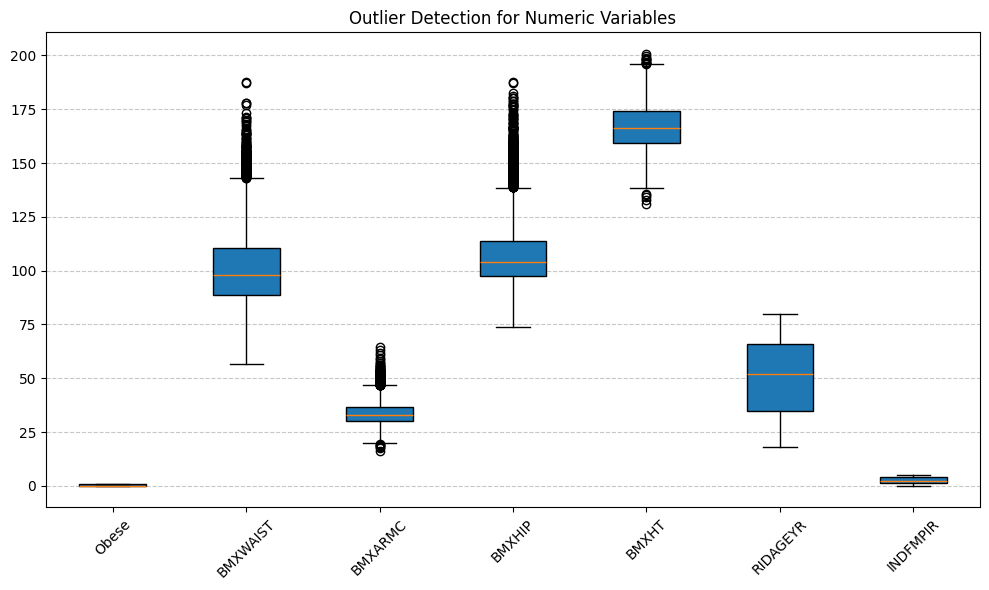

In [11]:
numeric_vars = ["Obese", "BMXWAIST", "BMXARMC", "BMXHIP", "BMXHT", "RIDAGEYR", "INDFMPIR"]

data = [df_clean[col].dropna() for col in numeric_vars]

plt.figure(figsize=(10,6))
plt.boxplot(data, patch_artist=True)
plt.title("Outlier Detection for Numeric Variables")
plt.xticks(range(1, len(numeric_vars)+1), numeric_vars, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("Boxplot.png")
plt.show()

## 11. Notebook Summary

### This notebook covered the key steps in preparing the NHANES dataset for analysis, including:

### - Cleaning and validating healthcare data

### - Handling missing values using appropriate imputation methods

### - Creating derived clinical variables, such as obesity status

### - Preparing an analysis‑ready dataset for statistical modeling

### - Exploring outliers to understand natural variation in the data
